<a href="https://colab.research.google.com/github/jaison-leonardo/data-science/blob/main/Flights_Delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

In [4]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Colab Notebooks/Big data files/flights/flights.csv"
flights = pd.read_csv(path)

Mounted at /content/drive


/tmp/ipykernel_276/941540628.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(path)


Analisis exploratorio

In [5]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
flights.shape

(5819079, 31)

In [7]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [8]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [9]:
flights.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [10]:
# Columnas relacionadas con retrasos
[col for col in flights.columns if "DELAY" in col.upper()]

['DEPARTURE_DELAY',
 'ARRIVAL_DELAY',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [11]:
# Limpieza de los datos
flights_clean = flights.dropna(subset=["DEPARTURE_DELAY"])

In [12]:
flights_clean.shape

(5732926, 31)

In [13]:
# 10 aerolíneas con más retrasos
delayed_flights = flights_clean[flights_clean["DEPARTURE_DELAY"] > 0]

In [14]:
top_delays = delayed_flights["AIRLINE"].value_counts().head(10)
top_delays

,count
AIRLINE,
WN,566807
DL,282463
UA,256550
AA,245904
OO,171572
EV,169897
B6,102061
MQ,93726
US,62565


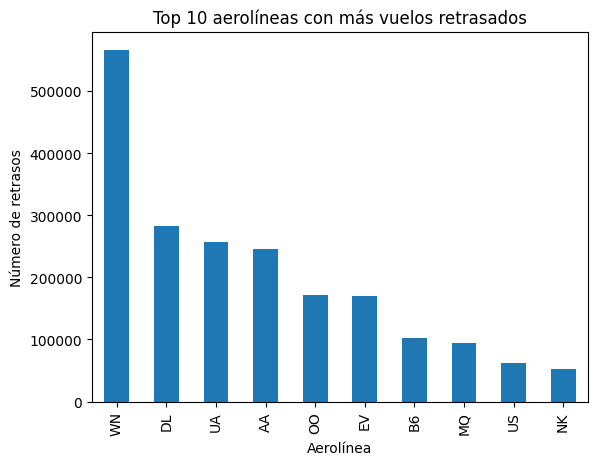

In [17]:
top_delays.plot(kind="bar")
plt.title("Top 10 aerolíneas con más vuelos retrasados")
plt.xlabel("Aerolínea")
plt.ylabel("Número de retrasos")
plt.show()

In [18]:
# Promedio de retraso por aerolínea
avg_delay_airline = flights_clean.groupby("AIRLINE")["DEPARTURE_DELAY"].mean().sort_values(ascending=False)
avg_delay_airline

,DEPARTURE_DELAY
AIRLINE,
NK,15.944766
UA,14.435441
F9,13.350858
B6,11.514353
WN,10.581986
MQ,10.125188
VX,9.022595
AA,8.900856
EV,8.715934


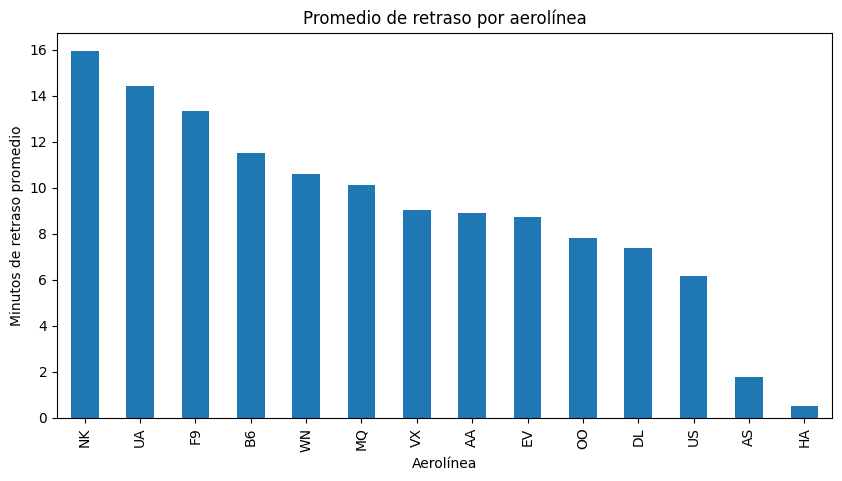

In [19]:
avg_delay_airline.plot(kind="bar", figsize=(10,5))
plt.title("Promedio de retraso por aerolínea")
plt.ylabel("Minutos de retraso promedio")
plt.xlabel("Aerolínea")
plt.show()

In [20]:
delay_by_month = flights_clean.groupby("MONTH")["DEPARTURE_DELAY"].mean()
delay_by_month

,DEPARTURE_DELAY
MONTH,
1,9.759471
2,11.885284
3,9.660903
4,7.721885
5,9.454144
6,13.986016
7,11.394664
8,9.932045
9,4.823560


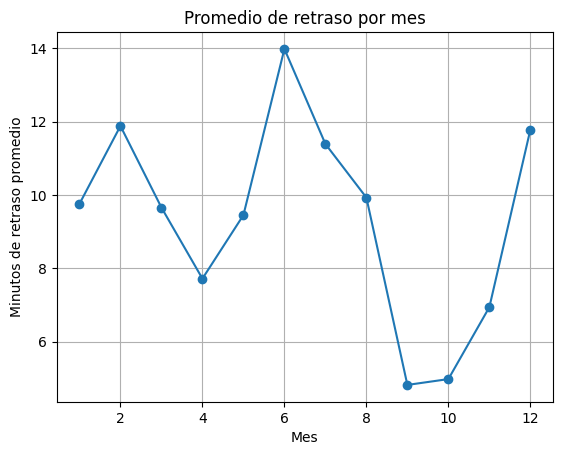

In [21]:
delay_by_month.plot(kind="line", marker="o")
plt.title("Promedio de retraso por mes")
plt.xlabel("Mes")
plt.ylabel("Minutos de retraso promedio")
plt.grid(True)
plt.show()